# Treasury Lock Validation — Pucci (2019)

**Reference:** M. Pucci, *Hedging the Treasury Lock*, Banca IMI, 2019. SSRN 3386521.

Visual validation of the pricebook `treasury_lock` module against the paper's results.

## Contents
1. T-Lock payoff vs forward proxy (overhedge)
2. Overhedge error vs yield move
3. Delta and gamma profiles
4. Forward price sensitivity to repo
5. Roll P&L surface

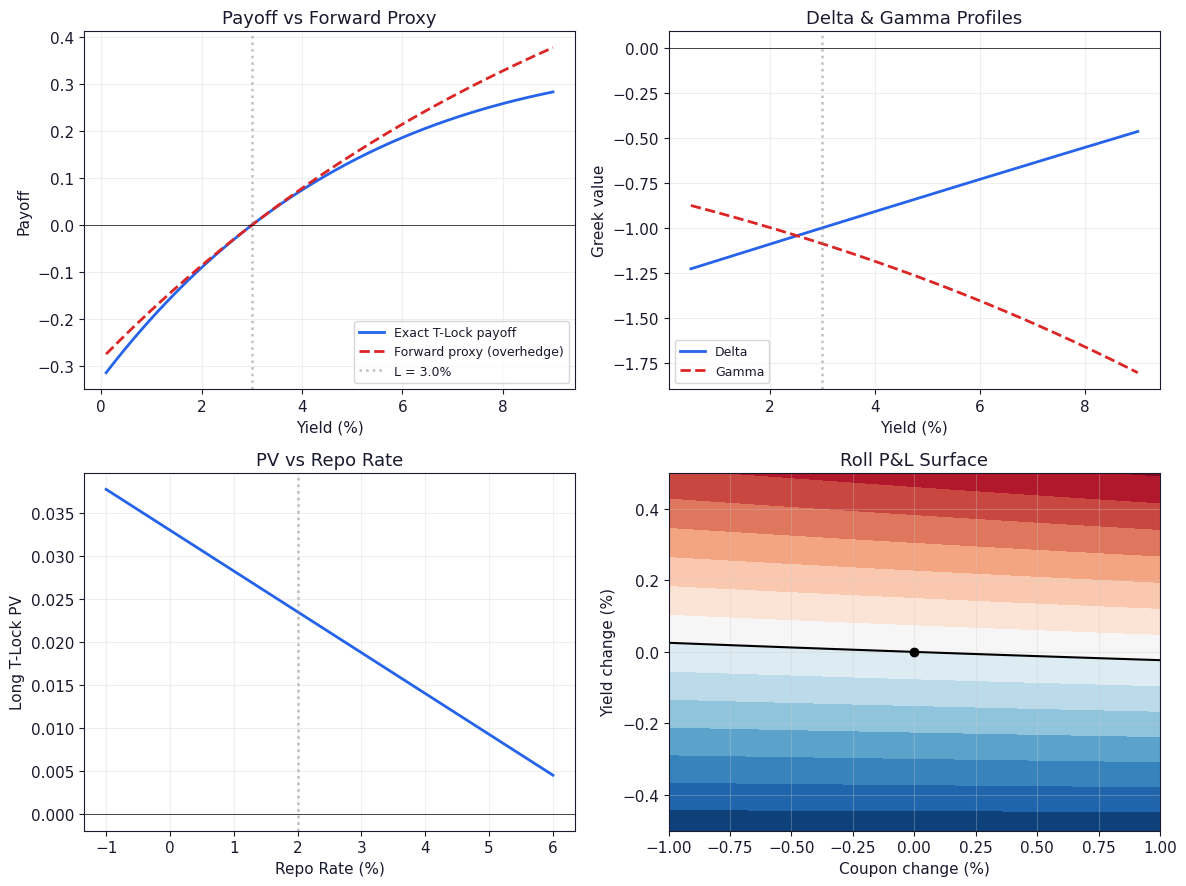

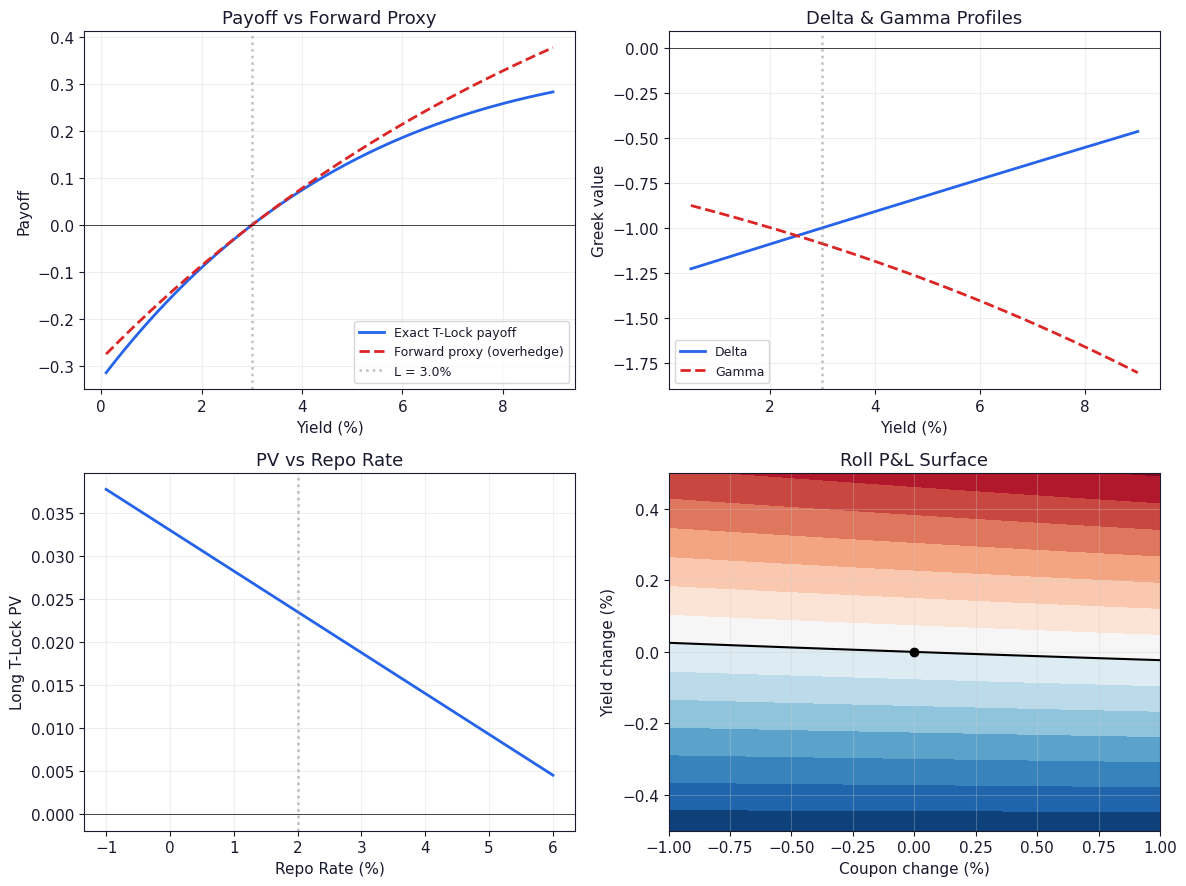

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "python"))

from datetime import date, timedelta
from pricebook.bootstrap import bootstrap
from pricebook.bond import FixedRateBond
from pricebook.treasury_lock import TreasuryLock
from pricebook.viz import plot, PlotBuilder

REF = date(2026, 4, 26)
deposits = [(REF + timedelta(days=91), 0.04), (REF + timedelta(days=182), 0.039)]
swaps = [(REF + timedelta(days=365), 0.038), (REF + timedelta(days=1825), 0.035),
         (REF + timedelta(days=3650), 0.034)]
curve = bootstrap(REF, deposits, swaps)
bond = FixedRateBond(REF, REF + timedelta(days=3650), coupon_rate=0.03)
tlock = TreasuryLock(bond, locked_yield=0.03, expiry=REF + timedelta(days=182), repo_rate=0.02)

# Default 2x2 dashboard
plot(tlock, curve)

## 1. T-Lock Payoff vs Forward Proxy (Paper Fig 1)

The exact T-Lock payoff is $g(y) = -D_y[P](y)(y - L)$ (RiskFactor times yield move).

The forward proxy is $P(L) - P(y)$ (price gap).

The proxy **strictly overhedges**: $P(L) - P(y) \geq g(y)$ for all $y \geq 0$, with equality only at $y = L$. This is because the bond price is convex in yield (Proposition 1).

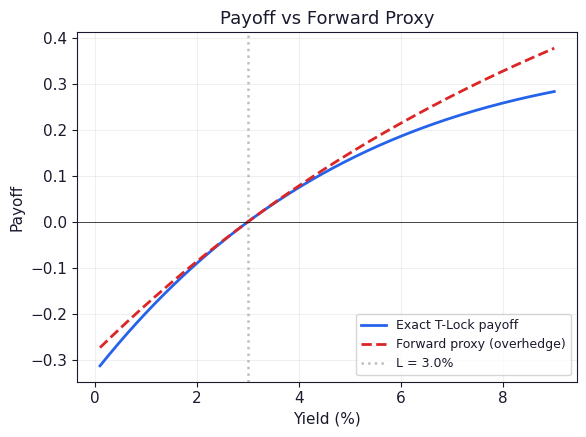

In [2]:
# Payoff vs forward proxy
PlotBuilder(tlock, curve).payoff().figure()

## 2. Overhedge Error vs Yield Move

The Taylor remainder $R_1(y) = P(y) - P(L) - D_y[P](L)(y-L) \geq 0$ (Proposition 1).

Bounded by $|R_1| \leq \frac{1}{2} M (y-L)^2$ where $M = (t_n-t)^2 + c \sum \alpha_i (t_i-t)^2$ (Eq 10-11).

For a 10Y benchmark with $c \sim 3\%$, Pucci computes $M \sim 150$.

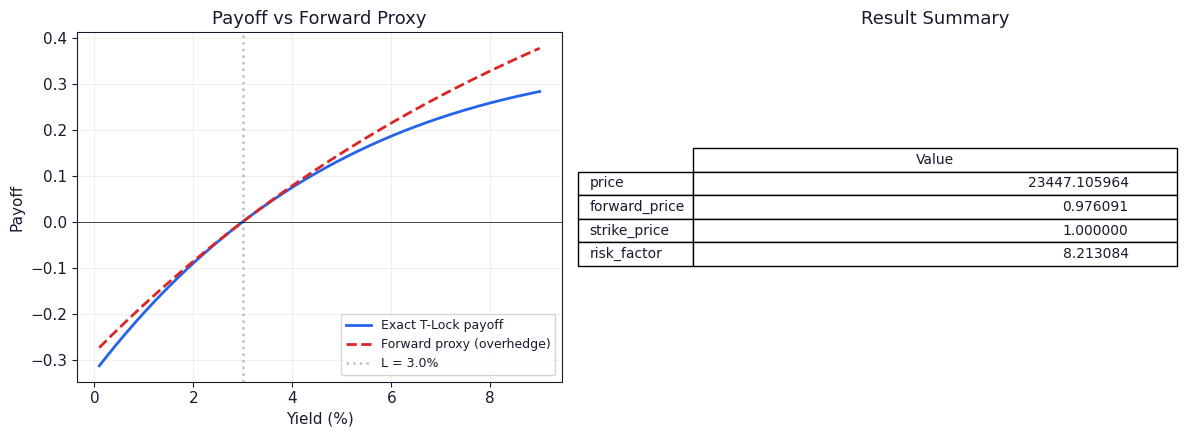

In [3]:
# Overhedge + summary
PlotBuilder(tlock, curve).payoff().summary().figure()

## 3. Delta and Gamma Profiles

**Delta** (Eq 14-15): $\Delta = D_P[g] < 0$ for a long T-Lock — short the bond's price.

**Gamma** (Eq 16-17): $\Gamma < 0$ near $L$ — negative convexity. The proxy earns gamma P&L: $\text{P\&L} \approx -\frac{1}{2}\Gamma(\Delta P)^2 \geq 0$ (Eq 20).

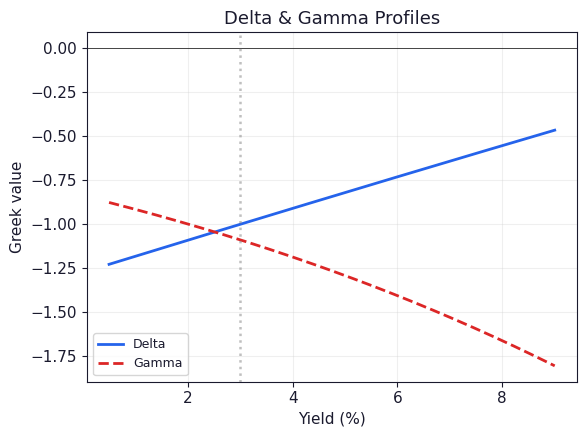

In [4]:
# Delta and gamma profiles
PlotBuilder(tlock, curve).greeks().figure()

## 4. Forward Price Sensitivity to Repo

From Eq (25): higher repo rate $\Rightarrow$ richer forward price $\Rightarrow$ lower forward IRR $\Rightarrow$ cheaper long T-Lock.

Specialness on the on-the-run benchmark makes the long T-Lock significantly more expensive.

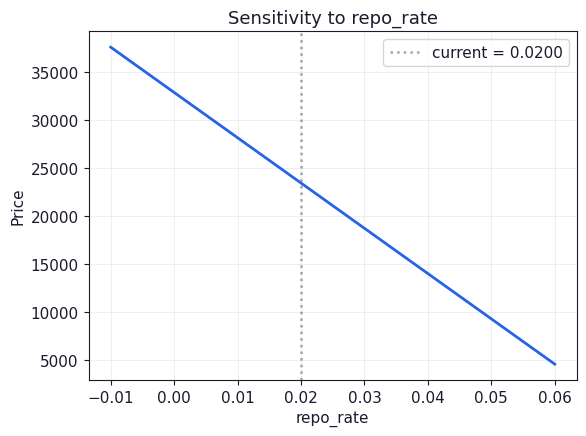

In [5]:
# Repo sensitivity
PlotBuilder(tlock, curve).sensitivity("repo_rate", low=-0.01, high=0.06).figure()

## 5. Roll P&L Surface

From Eq (31): roll P&L depends on coupon change $(\hat{c} - c)$ and yield change $(\hat{R} - R)$.

Vanishes when $\hat{c} = c$ AND $\hat{R} = R$ (no change at re-issue).

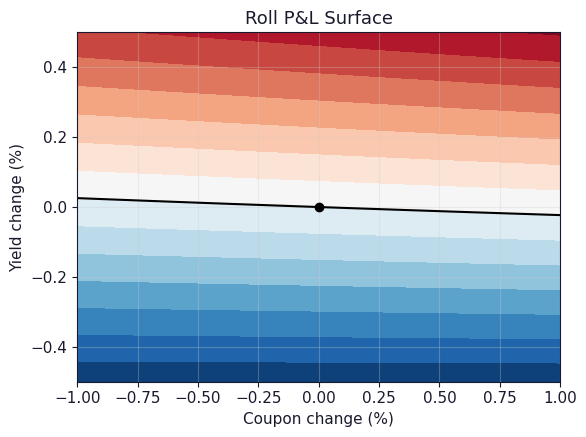

In [6]:
# Roll P&L surface
PlotBuilder(tlock, curve).roll_surface().figure()